In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import requests

# Folium library

We'll be using Folium, a mapping library. You may need to run the following cell (after un-commenting it) and restart the kernel.

In [3]:
#!pip install --user folium

In [4]:
import folium


# Capital Bikeshare Rides Data

In [5]:
#rides = pd.read_csv("../hw6/2011-capitalbikeshare-tripdata.zip")
#ROOT = "/home/cs/data202/CaptialBikeShare/"
ROOT = '../data/capital_bikeshare/'
rides = pd.concat([
    pd.read_csv(
        f"{ROOT}/2019{month:02d}-capitalbikeshare-tripdata.zip",
    usecols=["Duration", "Start date", "End date", "Start station number", "End station number", "Member type"])
    for month in range(1, 11)
])
rides.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3013027 entries, 0 to 337551
Data columns (total 6 columns):
Duration                int64
Start date              object
End date                object
Start station number    int64
End station number      int64
Member type             object
dtypes: int64(3), object(3)
memory usage: 160.9+ MB


In [6]:
print('{:,d}'.format(len(rides)))
rides.head()

3,013,027


,Duration,Start date,End date,Start station number,End station number,Member type
0,230,2019-01-01 00:04:48,2019-01-01 00:08:39,31203,31200,Member
1,1549,2019-01-01 00:06:37,2019-01-01 00:32:27,31321,31114,Casual
2,177,2019-01-01 00:08:46,2019-01-01 00:11:44,31104,31323,Casual
3,228,2019-01-01 00:08:47,2019-01-01 00:12:35,31281,31280,Member
4,1300,2019-01-01 00:12:29,2019-01-01 00:34:10,31014,31923,Member


In [23]:
rides['start_datetime'] = pd.to_datetime(rides['Start date'])
rides['start_date'] = rides['start_datetime'].dt.date
rides['start_month'] = rides['start_datetime'].dt.month
rides['start_hour'] = rides['start_datetime'].dt.hour

# Station Data
Let's get the [info about each station](https://gbfs.capitalbikeshare.com/gbfs/en/station_information.json).

Main things to notice in this section:

* **JSON is a useful format for structured data**.
* The `requests` library is a relatively easy way to automatically fetch data from the Web
* Pandas can make a DataFrame from a list of `dict`s.

In [11]:
station_info_response = requests.get("https://gbfs.capitalbikeshare.com/gbfs/en/station_information.json")
station_info_response_json = station_info_response.json()

In [12]:
stations = pd.DataFrame(station_info_response_json['data']['stations'])

In [13]:
print(len(stations), 'stations')
stations.head()

574 stations


,capacity,eightd_has_key_dispenser,eightd_station_services,electric_bike_surcharge_waiver,external_id,has_kiosk,lat,lon,name,region_id,rental_methods,rental_url,short_name,station_id
0,19,False,[{'id': '5029b3a1-a049-46f9-a13c-c7ffef2bb88c'...,False,08249be7-1f3f-11e7-bf6b-3863bb334450,True,38.902221,-77.059219,Georgetown Harbor / 30th St NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31215,72
1,23,False,[{'id': '6944e559-dc16-4a55-9125-e2c3256e294e'...,False,0824aa39-1f3f-11e7-bf6b-3863bb334450,True,38.900283,-77.029822,13th St & New York Ave NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31227,91
2,35,False,[{'id': '2a0089f1-ce95-4633-9471-61b0f70b7c08'...,False,0824c80d-1f3f-11e7-bf6b-3863bb334450,True,38.902061,-77.038322,17th & K St NW / Farragut Square,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31233,106
3,14,False,NaN,False,082469cc-1f3f-11e7-bf6b-3863bb334450,True,38.858971,-77.053230,Eads St & 15th St S,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31000,1
4,11,False,NaN,False,08246b69-1f3f-11e7-bf6b-3863bb334450,True,38.857250,-77.053320,18th St & S Eads St,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31001,2


In [14]:
stations['short_name'] = pd.to_numeric(stations['short_name'])

# Adding traffic data

We need to make sure to only use rides for stations we know the locations of.

In [51]:
missing_stations = set(rides['Start station number']) - set(stations['short_name'])
missing_stations

{31008, 32031, 32051}

In [53]:
rides_filt = rides[~rides['Start station number'].isin(missing_stations)]

In [54]:
hourly_ride_patterns = (
    rides_filt
    .groupby(['Start station number', 'start_month', 'start_hour'])
    .size().unstack(1).unstack(1)
    .fillna(0)
)

print(hourly_ride_patterns.shape)
hourly_ride_patterns.head()

(572, 240)


start_month            1                                                    \
start_hour             0    1    2    3    4    5     6     7     8     9    
Start station number                                                         
31000                 0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0   2.0   6.0   
31001                 0.0  0.0  0.0  0.0  0.0  0.0   1.0   5.0   7.0   7.0   
31002                 0.0  1.0  0.0  0.0  0.0  0.0   0.0   7.0  31.0  13.0   
31003                 0.0  0.0  0.0  0.0  0.0  0.0   7.0   4.0   8.0   3.0   
31004                 0.0  1.0  0.0  0.0  0.0  0.0  19.0  11.0  21.0   7.0   

start_month           ...    10                                                \
start_hour            ...    14    15    16    17    18    19    20   21   22   
Start station number  ...                                                       
31000                 ...  11.0   7.0  12.0  18.0  23.0   9.0   4.0  6.0  2.0   
31001                 ...  12.0   5.0  13.0  19.0  26.0  10.0   8.0  2.0  5.0   
31002                 ...  32.0  16.0  57.0  70.0  34.0  19.0  11.0  3.0  6.0   
31003                 ...   7.0  23.0  44.0  60.0  37.0  16.0   7.0  4.0  3.0   
31004                 ...   8.0   7.0   8.0  22.0  11.0   7.0   1.0  4.0  1.0   

start_month                
start_hour             23  
Start station number       
31000                 2.0  
31001                 5.0  
31002                 1.0  
31003                 2.0  
31004                 1.0  

[5 rows x 240 columns]

In [55]:
traffic_data = pd.merge(
    rides.groupby('Start station number').size().to_frame('n_departures'),
    rides.groupby('End station number').size().to_frame('n_arrivals'),
    left_index=True, right_index=True
)

stations_with_traffic = pd.merge(
    stations.set_index('short_name'),
    traffic_data,
    left_index=True, right_index=True,
    how='inner'
)
print(len(stations_with_traffic))
stations_with_traffic.head()

572


,capacity,eightd_has_key_dispenser,eightd_station_services,electric_bike_surcharge_waiver,external_id,has_kiosk,lat,lon,name,region_id,rental_methods,rental_url,station_id,n_departures,n_arrivals
31215,19,False,[{'id': '5029b3a1-a049-46f9-a13c-c7ffef2bb88c'...,False,08249be7-1f3f-11e7-bf6b-3863bb334450,True,38.902221,-77.059219,Georgetown Harbor / 30th St NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,72,10793,18035
31227,23,False,[{'id': '6944e559-dc16-4a55-9125-e2c3256e294e'...,False,0824aa39-1f3f-11e7-bf6b-3863bb334450,True,38.900283,-77.029822,13th St & New York Ave NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,91,9535,17630
31233,35,False,[{'id': '2a0089f1-ce95-4633-9471-61b0f70b7c08'...,False,0824c80d-1f3f-11e7-bf6b-3863bb334450,True,38.902061,-77.038322,17th & K St NW / Farragut Square,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,106,12632,21357
31000,14,False,NaN,False,082469cc-1f3f-11e7-bf6b-3863bb334450,True,38.858971,-77.053230,Eads St & 15th St S,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,1,1438,1268
31001,11,False,NaN,False,08246b69-1f3f-11e7-bf6b-3863bb334450,True,38.857250,-77.053320,18th St & S Eads St,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,2,1812,1646


Make sure the indices match between the hourly ride data and the station data.

In [62]:
stations_with_traffic = stations_with_traffic.reindex(index=hourly_ride_patterns.index)

['#a6cee3',
 '#1f78b4',
 '#b2df8a',
 '#33a02c',
 '#fb9a99',
 '#e31a1c',
 '#fdbf6f',
 '#ff7f00',
 '#cab2d6',
 '#6a3d9a',
 '#ffff99',
 '#b15928']

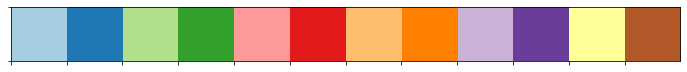

In [63]:
colors = sns.color_palette("Paired")
sns.palplot(colors)
color_codes = colors.as_hex()
color_codes

In [64]:
from sklearn.cluster import KMeans

One downside of k-means is we need to tell it how many clusters to look for.

In [65]:
km = KMeans(n_clusters=8)

In [66]:
X = hourly_ride_patterns.values

In [67]:
# clustering objects have a similar interface to classifiers:
km.fit(X)

stations_with_traffic['kmeans_cluster'] = km.predict(X)

stations_with_traffic['kmeans_cluster'].value_counts()

0    320
3     86
5     66
1     52
2     32
6      8
7      7
4      1
Name: kmeans_cluster, dtype: int64

In [68]:
cluster_to_color = dict(enumerate(color_codes.copy()))
stations_with_traffic['marker_color'] = stations_with_traffic['kmeans_cluster'].map(cluster_to_color)

In [70]:
m = folium.Map(
    location=[39, -77.],
    tiles='Stamen Toner',
    zoom_start=10
)

for station in stations_with_traffic.itertuples():
    folium.CircleMarker(
        location=[station.lat, station.lon],
        tooltip=station.name,
        color=station.marker_color,
        radius=2
    ).add_to(m)

display(m)

In [75]:
!pip install altair vega_datasets vega

     |████████████████████████████████| 2.2MB 2.2MB/s eta 0:00:01


In [76]:
import altair

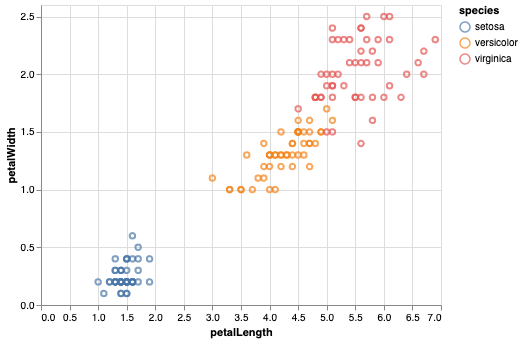

In [77]:
import altair as alt
from vega_datasets import data

# for the notebook only (not for JupyterLab) run this command once per session
alt.renderers.enable('notebook')

iris = data.iris()

alt.Chart(iris).mark_point().encode(
    x='petalLength',
    y='petalWidth',
    color='species'
)

In [137]:
m = folium.Map(
    location=[39, -77.],
    tiles='Stamen Toner',
    zoom_start=10
)

for station in stations_with_traffic.itertuples():
#     tmp_data = hourly_ride_patterns.loc[station.Index].to_frame('rides').reset_index()
    tmp_data = hourly_ride_patterns.loc[station.Index].to_frame('rides').reset_index().groupby('start_hour', as_index=False).mean()
    vis = alt.Chart(tmp_data).mark_line().encode(
        x='start_hour',
        y='rides',
#         color='start_month:O',
#         shape='start_month:O'
    )
    folium.CircleMarker(
        location=[station.lat, station.lon],
        tooltip=station.name,
        color=station.marker_color,
        radius=2,
        popup=folium.Popup(max_width=450).add_child(
            folium.VegaLite(vis, width=450, height=250))
    ).add_to(m)

display(m)

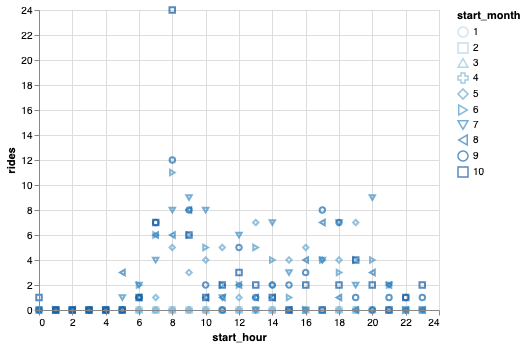

In [115]:
display(vis)

In [113]:
stations_with_traffic.itertuples()

<function Pandas.index(value, start=0, stop=9223372036854775807, /)>

In [92]:
hourly_ride_patterns.loc[31000]

start_month  start_hour
1            0              0.0
             1              0.0
             2              0.0
             3              0.0
             4              0.0
             5              0.0
             6              0.0
             7              0.0
             8              2.0
             9              6.0
             10             0.0
             11             4.0
             12             2.0
             13             1.0
             14             4.0
             15             1.0
             16             5.0
             17             3.0
             18             1.0
             19             0.0
             20             1.0
             21             0.0
             22             0.0
             23             1.0
2            0              1.0
             1              0.0
             2              0.0
             3              0.0
             4              0.0
             5              0.0
                

In [98]:
tmp_data = hourly_ride_patterns.loc[31000].to_frame('rides').reset_index()
tmp_data.head()

,start_month,start_hour,rides
0,1,0,0.0
1,1,1,0.0
2,1,2,0.0
3,1,3,0.0
4,1,4,0.0


In [132]:
tmp_data = hourly_ride_patterns.loc[31000].to_frame('rides').reset_index().groupby('start_hour', as_index=False).mean()
tmp_data.head()

,start_hour,start_month,rides
0,0,5.5,2.5
1,1,5.5,0.4
2,2,5.5,0.0
3,3,5.5,0.0
4,4,5.5,0.2


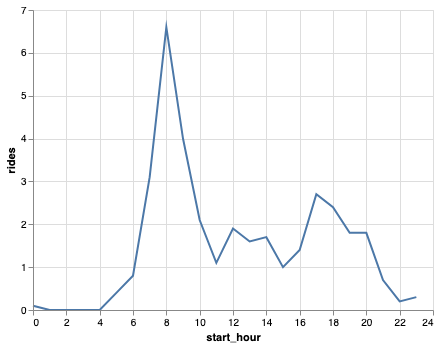

In [136]:
import altair as alt
c = alt.Chart(tmp_data).mark_line().encode(
    x='start_hour',
    y='rides',
)
c

In [130]:
c.to_dict()


{'config': {'view': {'width': 400, 'height': 300}, 'mark': {'tooltip': None}},
 'data': {'name': 'data-213d2922c14888b73b3850299d910d6b'},
 'mark': 'point',
 'encoding': {'x': {'type': 'quantitative', 'field': 'start_hour'},
  'y': {'type': 'quantitative', 'aggregate': 'mean', 'field': 'rides'}},
 '$schema': 'https://vega.github.io/schema/vega-lite/v3.4.0.json',
 'datasets': {'data-213d2922c14888b73b3850299d910d6b': [{'start_month': 1,
    'start_hour': 0,
    'rides': 0.0},
   {'start_month': 1, 'start_hour': 1, 'rides': 0.0},
   {'start_month': 1, 'start_hour': 2, 'rides': 0.0},
   {'start_month': 1, 'start_hour': 3, 'rides': 0.0},
   {'start_month': 1, 'start_hour': 4, 'rides': 0.0},
   {'start_month': 1, 'start_hour': 5, 'rides': 0.0},
   {'start_month': 1, 'start_hour': 6, 'rides': 0.0},
   {'start_month': 1, 'start_hour': 7, 'rides': 0.0},
   {'start_month': 1, 'start_hour': 8, 'rides': 0.0},
   {'start_month': 1, 'start_hour': 9, 'rides': 0.0},
   {'start_month': 1, 'start_hour'

In [110]:
folium.Vega(c)